# COMS W2132 Intermediate Computing in Python
## Graphs and Graph Algorithms

**Date**: April 8 & 13 2026
**Instructor**: Daniel Bauer <bauer@cs.columbia.edu> (some notes by Jan Janak)

**Reading**: Data Structures and Algorithms in Python, Chapter 14
---

* Graphs are the most general and versatile data structure we will see in this course
  * A tree is a graph.
  * A linked list is a graph.
* Graphs represent relations between pairs of entities.
* There are many standard graph algorithms -- if we can represent a problem as a graph, often these algorithms provide off-the-shelf solutions. 
* Applications: Computer networks, transportation, maps, electrical engineering diagrams, problem solving, etc.
* [Graph theory](https://en.wikipedia.org/wiki/Graph_theory): a branch of mathematics studying graph properties and algorithms.

<img style="float:left; padding: 0.5em;" src="https://janakj.org/w3132/images/graphs/nyc-subway.jpg" width=500/>
<img style="float:left; padding: 0.5em;" src="https://janakj.org/w3132/images/graphs/submarine-cables.png" width=500/>
<img style="float:left; padding: 0.5em;" src="https://janakj.org/w3132/images/graphs/twitter.png" width=500/>

## Graph Definition

* A **graph** $G = (V,E)$ consists of a set of vertices $V$ and a set of edges $E$. 
* **Vertices** are also known as nodes. 
* **Edges** are pairs of vertices. They are also known as arcs or links.
  * A pair of vertices connected by an edge is called **adjacent**.
  * An edge connected to a vertex is **incident** to that vertex.

<img src="https://github.com/cucs-python/public/blob/main/w2132/lectures/figures/graph.png?raw=true" width="200px"> 

V = {A,B,C,D,E,F}

E = {(A,B), (A,C), (B,C), (C,D), (C,E), (D,F), (E,F)}

* Edges can be **undirected** or **directed**. A graph with directed edges is called a directed graph or **digraph**.
    * Note: every undirected graph can be converted into a directed graph (how?)

<img src="https://github.com/cucs-python/public/blob/main/w2132/lectures/figures/digraph.png?raw=true" width="200px"> 

V = {A,B,C,D,E,F}

E = {(A,B), (B,C), (C,A), (C,D), (D,F), (F,E), (E,C)}

**Paths and Cycles:**
* A path is a sequence of vertices. Example (A,B,C,D,F)
* A **circuit** is any path that starts and ends at the same vertex (vertices may repeat), Example (A,B,C,D,F,E,C,A)
* A **cycle** or **simple circuit** is a circuit in which no vertex repeats (other than the first and last one). Example (A,B,C,A)
* A connected graph with no cycles is called a **tree**. If it is not connected, it's called a **forest**. (Note: this is a weaker definition than trees discussed earlier in the course


**Reachability and Connectedness**:
* A vertex $t$ is **reachable** from vertex $s$ if there is some path from $s$ to $t$.
* An undirected graph is **connected** if every vertex is reachable from any other vertex.
* A directed graph is **strongly connected** if every vertex is reachable from any other vertex. 
  * Example: The digraph above is strongly connected. But if we flip edge (E,F) to (F,E), no other vertex is reachable from F and the graph is no longer strongly connected (but is still **weakly** connected).

* In a **complete** graph, every vertex is *adjacent* to every other vertex.

## Graph Data Structures

* **Adjacency Matrix**
* **Adjacency List** representation.
    * OOP based approach (each vertex object maintains a list of outgoing edges)
* **Adjacency Map**
    * Map based representation to find outgoing edges more efficiently.
 
Easy to implement an adjacency list or adjacency map representation using built-in Python data structures. 

There are also packages for representing and visualizing graphs, such as [NetworkX](https://networkx.org/) (graph data structures and extensive inventory of graph algorithms) and [pyGraphviz](https://pygraphviz.github.io/) (visualization/ graph layouts)

### Adjacency Matrix 

* Represent edges as cells in a matrix. Rows and columns correspond to vertices.
* Very efficient to check if an edge exists $O(1)$, but slow to find all adjacent edges for a given edge $s$: $O(|V|)$
* Space requirement ($|V|^2$) -- good for dense graphs (close to complete), but problematic for *sparse* graphs (many missing edges, these are more typical).
* Can be implemented with low overhead in languages like C, less commonly used in Python. 

<img src="https://github.com/cucs-python/public/blob/main/w2132/lectures/figures/adj_matrix.png?raw=true" width="600px">

### Adjacency List

Each vertex maintains all outgoing edges (or all adjacent vertices) as a list. 

* Check if an edge exists and finding a specific edge: O(out_degree(v)) for a vertex v
* space requirement $O(|V| + |E|)$

Traditional OOP representation:

In [43]:
class Vertex:
    
    def __init__(self, name, outgoing = []): 
        self.name = name
        self.outgoing = [] # store all edges pointing away from this vertex 
        # Note: In some implementations, we may also want to store the incoming edges.
        self.payload = None 
    
    def add_edge(self, edge): 
        for uv in self.outgoing: 
            if uv.v == edge.v: 
                raise KeyError(f"Edge {edge} already exists in graph.")
        self.outgoing.append(edge)

    def __repr__(self): 
        return f"{self.name} -> {self.outgoing}"

class Edge: 
    def __init__(self, origin_u, destination_v): 
        self.u = origin_u
        self.v = destination_v

    def __repr__(self): 
        return f"({self.u.name}, {self.v.name})"

class Graph: 
    def __init__(self): 
        self.vertices = {} # dictionary to find the vertices by name.

    def add_vertex(self, name): 
        if name in self.vertices: 
            raise KeyError(f"Vertex {name} already exists in graph")

        new_v = Vertex(name)
        self.vertices[name] = new_v

    def add_edge(self, origin_name, destination_name): 
        if not origin_name in self.vertices: 
            self.add_vertex(origin_name)
        if not destination_name in self.vertices: 
            self.add_vertex(destination_name)

        orig = self.vertices[origin_name]
        dest = self.vertices[destination_name]    

        new_edge = Edge(orig,dest) 
        orig.add_edge(new_edge)

    def __repr__(self):
        result = ""
        for v in self.vertices: 
            result += repr(self.vertices[v]) + "\n"
        return result


In [20]:
g = Graph()

In [21]:
g

In [46]:
v = Vertex("A")
w = Vertex("B")
v.add_edge(Edge(v,w))

In [47]:
v

A -> [(A, B)]

In [50]:
g = Graph()
g.add_vertex("A")
g
g.add_edge("A","B")
g

A -> [(A, B)]
B -> []

A compact way of representing a graph in adjancency list representation in Python looks like this: 

In [191]:
graph = {'A': ['B'], 
         'B': ['C'],
         'C': ['A','D'],
         'D': ['F'],
         'E': ['C'],
         'F': ['E']
        }

### Adjacency Map
Store outgoing edges indexed by target vertex. 
* Check if an edge exists and finding a specific edge: $O(1)$ expected
* space requirement $O(|V| + |E|)$

In [52]:
graph = {'A': {'B':1}, 
         'B': {'C':1},
         'C': {'A':1,'D':1},
         'D': {'F':1},
         'E': {'C':1},
         'F': {'E':1}
        }

In [54]:
graph["C"]["E"]

KeyError: 'E'

Finally, there are Python packages that provide efficient graph representations and algorithms. The most common one is [networkx](https://networkx.org/en/).

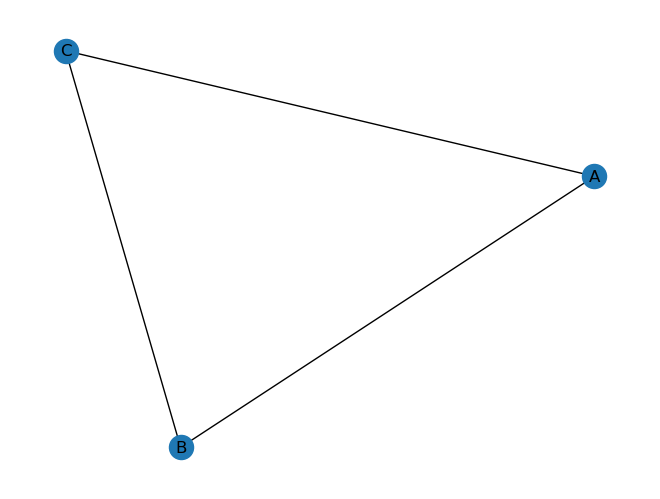

In [323]:
import networkx as nx

g = nx.Graph()
g.add_edge("A","B")
g.add_edge("B","C")
g.add_edge("C","A")

nx.draw(g,with_labels=True)

## Graph Traversals

* Systematically explore a graph by examining all its vertices and edges
* Similar to tree traversal (not surprising, a tree is a graph)
* Efficient traversal: visit all vertices and edges in linear time
* Applications
  * Reachability tests, Testing for connectedness
  * Determine whether a directed graph is acyclic
  * Computing (shortest) paths between vertices

**Depth First Search Traversal**
* Recall the recursive algorithms for traversing a tree. We can adjust this to a graph.


In [392]:
graph = {'A': {'B':1}, 
         'B': {'C':1},
         'C': {'A':1,'D':1},
         'D': {'F':1},
         'E': {'C':1},
         'F': {'E':1}
        }

In [55]:
def dfs_recursive(graph, u):
    # Visit vertex u
    print(u)
    for v in graph[u]:
        dfs_recursive(graph, v) # discover and visit vertex v

In [56]:
graph = {'A': ['B'], 
         'B': ['C'],
         'C': ['A','D'],
         'D': ['F'],
         'E': ['C'],
         'F': ['E']
        }

dfs_recursive(graph, "A") # DFS traversal starting at A

A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B
C
A
B


RecursionError: maximum recursion depth exceeded

If the graph contains a cycle, this doesn't work, because we we will visit the same vertex repeatedly.
A simple way to avoid this is to use a "tabu" / visited set. 

In [57]:
def dfs_recursive(graph, u, visited=set()):
    if u in visited: 
        return
        
    # Visit vertex u
    visited.add(u)
    print(u)
    for v in graph[u]:        
        dfs_recursive(graph, v, visited) # discover and visit vertex v

In [58]:
dfs_recursive(graph, "A")

A
B
C
D
F
E


Recursion uses the runtime stack to keep track of vertices that still need ot be visited. We can also use a stack directly. 

Note that each vertex in the graph undergoes three stages (lifecycle of a vertex). 
* Not yet discovered
* Discovered, vertex is added to the stack
* Visited, vertex is popped off the stack and added to the result

In the recursive implementation above, we use a "tabu" set to ensure we never visit a vertex twice. Note that this might still result in vertices being discovered and added to the stack multiple times. For efficiency, it's better to check if a vertex has been discovered / seen before. 

In [63]:
def dfs(graph, start):

    stack = [] # use as a stack, using append and pop()
    stack.append(start)

    seen = set() # store each vertex when discovered
    seen.add(start)
    
    while stack: # as long as the stack is not []
        
        u = stack.pop() # visit u
        print(u)

        for v in graph[u]:  # discover v
            if not v in seen: # ensure we discover each vertex only once
                seen.add(v)
                stack.append(v)                

In [64]:
dfs(graph, "A")

A
B
C
D
F
E


**Breadth First Search Traversal**

Instead of a stack, we can use a queue.

In [65]:
def bfs(graph, start):

    queue = [] # use as a stack, using append and pop()
    queue.append(start)

    seen = set()
    seen.add(start)
    
    while queue: # as long as the stack is not []
        
        u = queue.pop(0) # visit u
        print(u)
        for v in graph[u]:  # discover v        
            if not v in seen:                
                seen.add(v)
                queue.append(v)


In [69]:
graph = {
    "A": ["C","B"],
    "B": ["D","E"],
    "C": [],
    "D": ["A"], 
    "E": ["C"]}

In [70]:
dfs(graph, "A") 

A
B
E
D
C


In [71]:
bfs(graph, "A")

A
C
B
D
E


In [438]:
graph = {'A': {'B':1}, 
         'B': {'C':1},
         'C': {'A':1,'D':1,'G':1},
         'D': {'F':1},
         'E': {'C':1},
         'F': {'E':1},
         'G': {}
        }

In [440]:
backptr, cost = bfs(graph, "A")

A
B
C
D
G
F
E


In [442]:
backptr

{'B': 'A', 'C': 'B', 'D': 'C', 'G': 'C', 'F': 'D', 'E': 'F'}

In [444]:
cost

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'G': 3, 'F': 4, 'E': 5}

The BFS algorithm visits vertices in the order in which they are discovered because it uses a queue. 
The vertices are discovered in order of their distance from the origin. Vertices that are 1 edge away from the origin will be visited before vertices that are 2 edges away, etc. 

We can modify the BFS algorithm to keep track of the distances (cost), as well as the previous vertex on the shortest path to *any* other vertex in the graph. This is known as the *single source shortest path* problem. 

Important: The first time a vertex is discovered, BFS has found the shortest path to it (if there as a shorter path, BFS would have found it earlier because all vertices are visited in order of their distance from the start vertex)!

After the algorithm computes this information, we can find the shortest path from the origin $s$ to a specific vertex $t$ by backtracking our steps.

(example in a different file: exploring a maze)

Another example: Shortest paths in wikipedia

In [13]:
import requests

topic = "Leonard_Euler"
headers = {
    "User-Agent": "WikiGraphExample/1.0 (bauer@cs.columbia.edu)",  # required/descriptive
    "Accept": "application/json",
}

response = requests.get(url = "https://en.wikipedia.org/api/rest_v1/page/summary/" + topic,headers = headers )
if response.status_code == 200:
    print(response.json()["extract"])
    

Leonhard Euler was a Swiss polymath who was active as a mathematician, physicist, astronomer, logician, geographer, music theorist and engineer. He founded the studies of graph theory and topology and made influential discoveries in many other branches of mathematics, such as analytic number theory, complex analysis, and infinitesimal calculus. He also introduced much of modern mathematical terminology and notation, including the notion of a mathematical function. He is known for his work in mechanics, fluid dynamics, optics, astronomy, and music theory. Euler has been called a "universal genius" who "was fully equipped with almost unlimited powers of imagination, intellectual gifts and extraordinary memory". He spent most of his adult life in Saint Petersburg, Russia, and in Berlin, then the capital of Prussia.


In [14]:
import requests

def get_outgoing_links(title, limit=100):
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "titles": title,
        "prop": "links",
        "pllimit": limit,  # 'max' for full limit (requires continuation)
        "format": "json"
    }

    response = requests.get(url, params=params, headers=headers)
    if response.status_code == 200:
        data = response.json()
        pages = data.get("query", {}).get("pages", {})
        links = []
        for page_id, page_data in pages.items():
            for link in page_data.get("links", []):
                links.append(link["title"])
        return links
    else:
        return f"Error {response.status_code}: Could not retrieve links."

title = "Columbia_University"
outgoing_links = get_outgoing_links(title)
print(outgoing_links)

['110th Street (Manhattan)', '115th Street Library', '116th Street (Manhattan)', '116th Street–Columbia University (IRT Broadway–Seventh Avenue Line)', '116th Street–Columbia University station', '125th Street (Manhattan)', '12 Angry Men (1957 film)', '133rd Street (Manhattan)', '14th Dalai Lama', '1776 (book)', '1962–1963 New York City newspaper strike', '1968 Columbia University protests', '1 (New York City Subway service)', '2008 financial crisis', '2021–2022 Columbia University strike', '2024 Columbia University pro-Palestinian campus occupations', '47 The American Sign Language and English Secondary School', '4 Times Square', '53rd Street Library', 'A. Philip Randolph Campus High School', 'A. W. Kuchler', "A Jailhouse Lawyer's Manual", 'A Visit From St. Nicholas', 'A cappella', 'Abdul Zahir (politician)', 'Abraham Joshua Heschel School', 'Abram Hewitt', 'Academic Ranking of World Universities', 'Academic regalia of Columbia University', 'Academy Awards', 'Academy Bus Lines', 'Adol

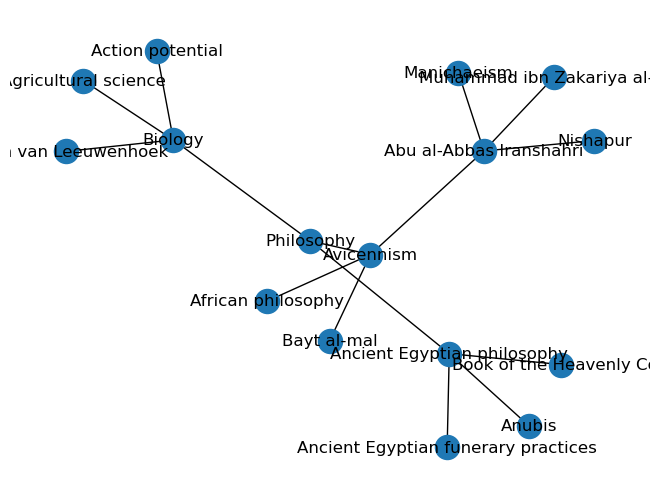

In [16]:
import networkx as nx
import random

g = nx.Graph()
start = "Philosophy"

todo = [start]

for i in range(5): #while todo: # todo is not empty 

    current_page = todo.pop(0) # queue 
    outgoing_links = get_outgoing_links(current_page, limit=100)
    random.shuffle(outgoing_links)
    outgoing_links = outgoing_links[:3]

    for page in outgoing_links:
        #print(start, page.replace(" ","_"))
        g.add_edge(current_page, page)
        todo.append(page)

nx.draw(g,with_labels=True)